# Task 2: Understanding ViT

2.1: Using a pre-trained ViT for Image Classification

In [5]:
import torch
import torchvision
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np
import urllib.request
import json

In [6]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [7]:

# ── 1. Load pretrained ViT-B/16 ───────────────────────────────────────────────

model_vit = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1)
model_vit = model_vit.to(device)
model_vit.eval()

total_params = sum(p.numel() for p in model_vit.parameters())
print(f"ViT-B/16 loaded — {total_params:,} parameters")
print(f"Patch size     : 16×16")
print(f"Embedding dim  : 768")
print(f"Attention heads: 12")
print(f"Transformer layers: 12")

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:02<00:00, 160MB/s]


ViT-B/16 loaded — 86,567,656 parameters
Patch size     : 16×16
Embedding dim  : 768
Attention heads: 12
Transformer layers: 12


In [8]:

# ── 2. ImageNet class labels ──────────────────────────────────────────────────
# Download the ImageNet class index

url = "https://raw.githubusercontent.com/anishathalye/imagenet-simple-labels/master/imagenet-simple-labels.json"
urllib.request.urlretrieve(url, "imagenet_labels.json")
with open("imagenet_labels.json") as f:
    imagenet_labels = json.load(f)   # list of 1000 class names

print(f"\nLoaded {len(imagenet_labels)} ImageNet class labels")


Loaded 1000 ImageNet class labels


In [9]:
# ── 3. Preprocessing transform ────────────────────────────────────────────────
# Must match what ViT was trained with

vit_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

denorm = transforms.Normalize(
    mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
    std=[1/0.229, 1/0.224, 1/0.225]
)

In [10]:
# STL-10

stl10 = torchvision.datasets.STL10(
    root='./data', split='test', download=True
)

STL10_CLASSES = ['airplane', 'bird', 'car', 'cat', 'deer',
                 'dog', 'horse', 'monkey', 'ship', 'truck']

# Pick one image from 3 different classes
target_classes = ['dog', 'cat', 'bird']
test_images = {}

for img, label in stl10:
    class_name = STL10_CLASSES[label]
    if class_name in target_classes and class_name not in test_images:
        test_images[class_name] = img   # already a PIL image
    if len(test_images) == len(target_classes):
        break

print(f"Loaded {len(test_images)} images: {list(test_images.keys())}")

100%|██████████| 2.64G/2.64G [03:35<00:00, 12.3MB/s]


Loaded 3 images: ['dog', 'cat', 'bird']


In [11]:
# ── 5. Inference ──────────────────────────────────────────────────────────────
def predict(model, img_pil, transform, labels, top_k=5):
    x = transform(img_pil).unsqueeze(0).to(device)
    with torch.no_grad():
        logits = model(x)
    probs = torch.softmax(logits, dim=-1)[0]
    top_probs, top_indices = probs.topk(top_k)
    return [(labels[i.item()], p.item()) for i, p in zip(top_indices, top_probs)]


===== ViT-B/16 Top-5 Predictions =====

True class : dog
  Top-1: Whippet                             80.70%
  Top-2: Ibizan Hound                        1.48%
  Top-3: Irish Wolfhound                     1.11%
  Top-4: English foxhound                    0.29%
  Top-5: Bedlington Terrier                  0.14%

True class : cat
  Top-1: tabby cat                           32.83%
  Top-2: tiger cat                           29.62%
  Top-3: Egyptian Mau                        25.54%
  Top-4: Cardigan Welsh Corgi                0.36%
  Top-5: Pembroke Welsh Corgi                0.20%

True class : bird
  Top-1: goose                               84.37%
  Top-2: black grouse                        0.23%
  Top-3: lakeshore                           0.16%
  Top-4: water snake                         0.11%
  Top-5: indri                               0.09%


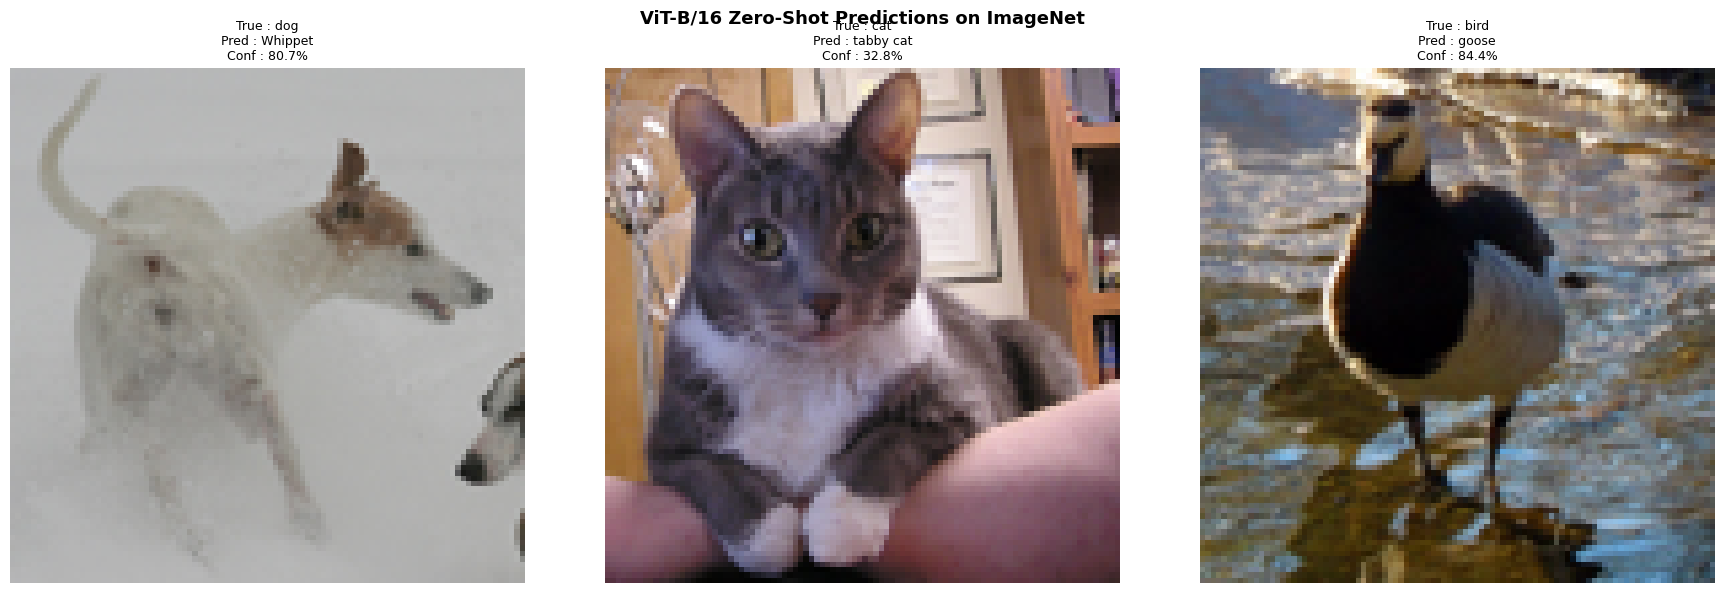

In [12]:
# ── 6. Visualize ──────────────────────────────────────────────────────────────

fig, axes = plt.subplots(1, len(test_images), figsize=(6 * len(test_images), 6))
if len(test_images) == 1:
    axes = [axes]

print("\n===== ViT-B/16 Top-5 Predictions =====")
for ax, (true_label, img_pil) in zip(axes, test_images.items()):
    preds = predict(model_vit, img_pil, vit_transform, imagenet_labels)
    top1_label, top1_prob = preds[0]

    ax.imshow(img_pil)
    ax.axis('off')
    ax.set_title(
        f"True : {true_label}\n"
        f"Pred : {top1_label}\n"
        f"Conf : {top1_prob*100:.1f}%",
        fontsize=9
    )

    print(f"\nTrue class : {true_label}")
    for i, (label, prob) in enumerate(preds):
        print(f"  Top-{i+1}: {label:<35} {prob*100:.2f}%")

plt.suptitle('ViT-B/16 Zero-Shot Predictions on ImageNet',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('task2_1_vit_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

2.2: Visualizing Patch Attention

In [13]:
import types
import torch.nn.functional as F

In [14]:
# ── 1. Patch last encoder block to capture attention weights ──────────────────
# torchvision ViT calls self_attention with need_weights=False by default
# We override the last block's forward to force need_weights=True
# average_attn_weights=False gives us per-head weights (batch, heads, seq, seq)
# which we can average for 2.2 and inspect individually for 2.3

attention_store = {}
last_block = model_vit.encoder.layers[-1]

def patched_forward(self, input):
    x = self.ln_1(input)
    x_attn, attn_weights = self.self_attention(
        x, x, x,
        need_weights=True,
        average_attn_weights=False   # keep per-head: (batch, heads, seq, seq)
    )
    attention_store['weights'] = attn_weights.detach().cpu()
    x = self.dropout(x_attn)
    x = x + input
    y = self.ln_2(x)
    y = self.mlp(y)
    return x + y

last_block.forward = types.MethodType(patched_forward, last_block)
print("Last encoder block patched to capture attention weights")

Last encoder block patched to capture attention weights


In [15]:
# ── 2. Helper: extract attention map for one image ────────────────────────────
def get_attention_map(model, img_pil, transform, device):
    """
    Returns:
      attn_avg   : (14, 14) numpy array — CLS attention averaged across heads
      attn_heads : (12, 14, 14) numpy array — CLS attention per head
    """
    x = transform(img_pil).unsqueeze(0).to(device)

    with torch.no_grad():
        _ = model(x)    # forward pass triggers patched_forward

    # attn_weights: (1, 12, 197, 197)
    # 197 = 196 patches + 1 CLS token (index 0)
    attn = attention_store['weights'][0]   # (12, 197, 197)

    # CLS token row → attention from CLS to each patch token
    cls_attn = attn[:, 0, 1:]             # (12, 196) — skip CLS-to-CLS at index 0

    # Average across heads → (196,) then reshape to 14×14
    attn_avg = cls_attn.mean(dim=0).reshape(14, 14).numpy()

    # Per-head → (12, 14, 14)
    attn_heads = cls_attn.reshape(12, 14, 14).numpy()

    return attn_avg, attn_heads

In [16]:
# ── 3. Helper: overlay attention map on image ─────────────────────────────────
def overlay_attention(img_pil, attn_14x14, alpha=0.5):
    """
    Upsample 14x14 attention map to 224x224 and overlay as heatmap on image.
    Returns a matplotlib-ready numpy array.
    """
    import torch.nn.functional as F

    # Upsample to 224×224
    attn_tensor = torch.tensor(attn_14x14).unsqueeze(0).unsqueeze(0).float()  # (1,1,14,14)
    attn_upsampled = F.interpolate(attn_tensor, size=(224, 224),
                                   mode='bicubic', align_corners=False)
    attn_upsampled = attn_upsampled.squeeze().numpy()

    # Normalize to [0, 1]
    attn_norm = (attn_upsampled - attn_upsampled.min()) / \
                (attn_upsampled.max() - attn_upsampled.min() + 1e-8)

    # Resize image to 224×224 for alignment
    img_resized = np.array(img_pil.resize((224, 224))) / 255.0

    # Red heatmap overlay
    heatmap = plt.cm.jet(attn_norm)[..., :3]   # (224, 224, 3)
    overlay = alpha * heatmap + (1 - alpha) * img_resized
    overlay = np.clip(overlay, 0, 1)

    return img_resized, attn_norm, overlay

Extracting and visualizing attention maps...
  dog: attention range [0.000, 1.000]
  cat: attention range [0.000, 1.000]
  bird: attention range [0.000, 1.000]


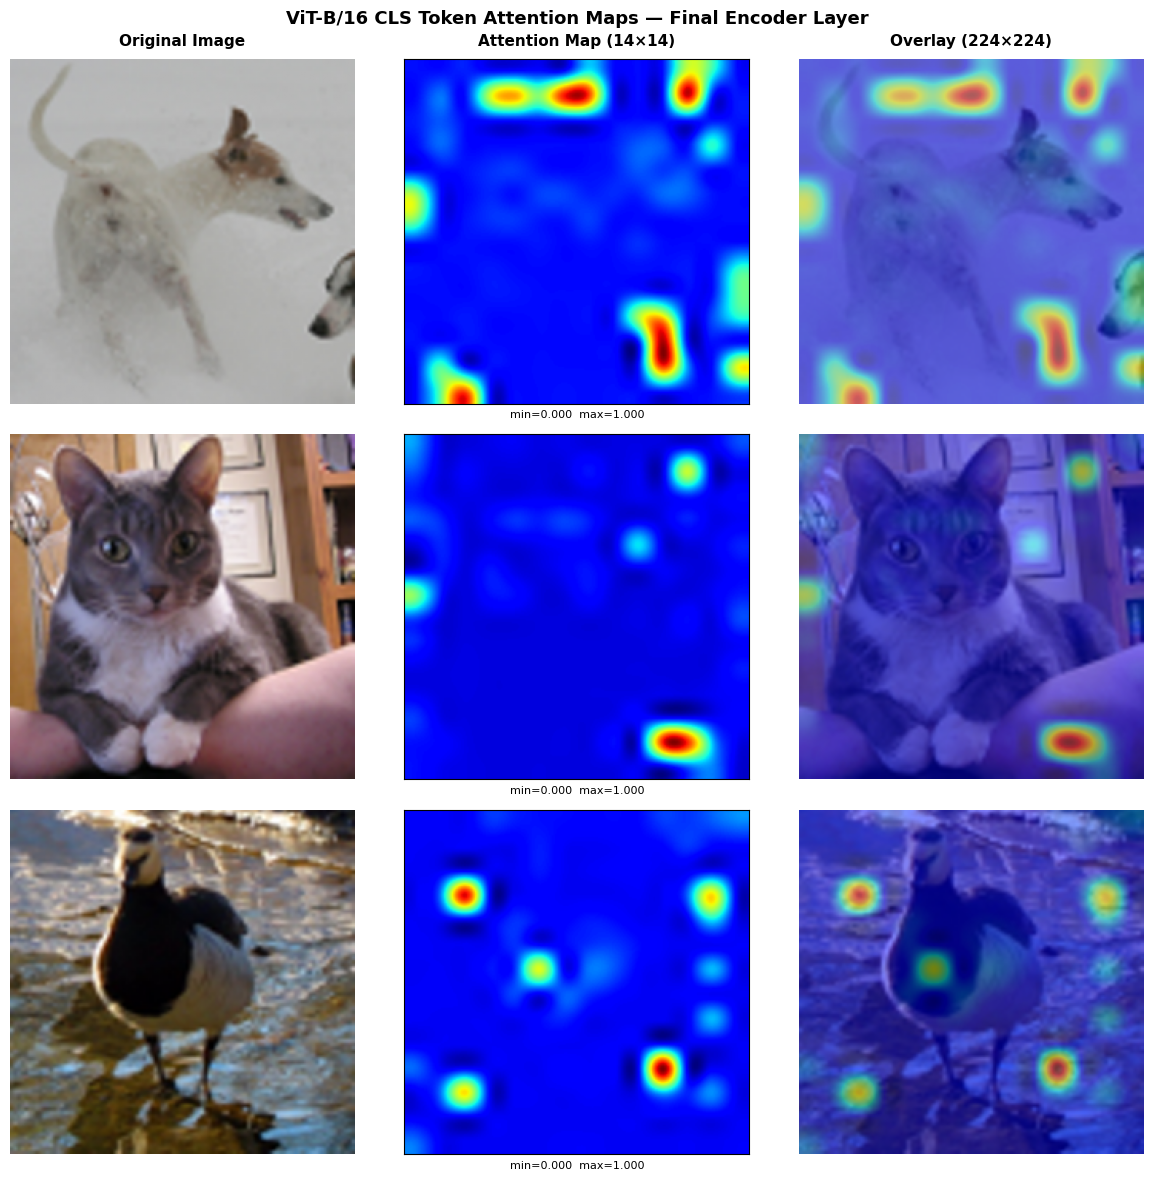

In [17]:
# ── 4. Visualize for all test images ─────────────────────────────────────────
n = len(test_images)
fig, axes = plt.subplots(n, 3, figsize=(12, 4 * n))
if n == 1:
    axes = axes[np.newaxis, :]   # keep 2D indexing consistent

col_titles = ['Original Image', 'Attention Map (14×14)', 'Overlay (224×224)']
for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontsize=11, fontweight='bold', pad=10)

print("Extracting and visualizing attention maps...")
for row, (true_label, img_pil) in enumerate(test_images.items()):

    attn_avg, attn_heads = get_attention_map(model_vit, img_pil, vit_transform, device)

    img_resized, attn_norm, overlay = overlay_attention(img_pil, attn_avg)

    # Column 0 — original image
    axes[row, 0].imshow(img_resized)
    axes[row, 0].set_ylabel(true_label, fontsize=10, fontweight='bold', rotation=90,
                             labelpad=10)

    # Column 1 — raw 14×14 attention map
    axes[row, 1].imshow(attn_norm, cmap='jet')
    axes[row, 1].set_xlabel(f"min={attn_norm.min():.3f}  max={attn_norm.max():.3f}",
                             fontsize=8)

    # Column 2 — overlay
    axes[row, 2].imshow(overlay)

    for ax in axes[row]:
        ax.axis('off')
    axes[row, 1].axis('on')   # keep ticks off but let xlabel show
    axes[row, 1].set_xticks([])
    axes[row, 1].set_yticks([])

    print(f"  {true_label}: attention range [{attn_norm.min():.3f}, {attn_norm.max():.3f}]")

plt.suptitle('ViT-B/16 CLS Token Attention Maps — Final Encoder Layer',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('task2_2_attention_maps.png', dpi=150, bbox_inches='tight')
plt.show()

2.3: Analyze the Attention Map

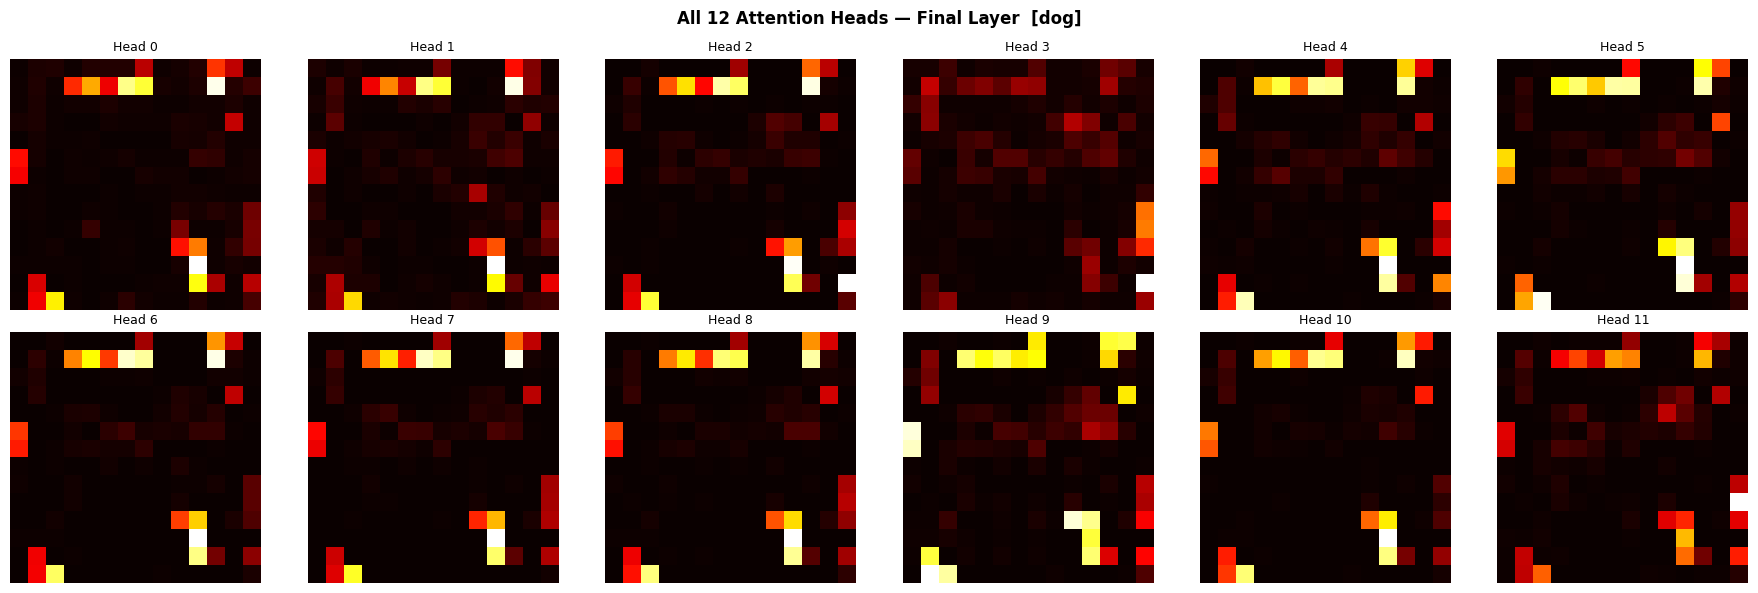

In [18]:
# ── 2.3  Attention head specialization visualization ─────────────────────────
# Plot all 12 heads for the first test image to check for specialization.

first_label = list(test_images.keys())[0]
first_img   = test_images[first_label]

_, attn_heads_first = get_attention_map(model_vit, first_img, vit_transform, device)
# attn_heads_first : (12, 14, 14)

n_heads = attn_heads_first.shape[0]   # 12
fig, axes = plt.subplots(2, 6, figsize=(18, 6))
axes = axes.flatten()

for h in range(n_heads):
    head_map = attn_heads_first[h]
    head_map_norm = (head_map - head_map.min()) / (head_map.max() - head_map.min() + 1e-8)
    axes[h].imshow(head_map_norm, cmap='hot')
    axes[h].set_title(f'Head {h}', fontsize=9)
    axes[h].axis('off')

plt.suptitle(f'All 12 Attention Heads — Final Layer  [{first_label}]',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('task2_3_attention_heads.png', dpi=150, bbox_inches='tight')
plt.show()

2.4: Patch-Masking Experiment

In [19]:
import torch
import types
import torch.nn.functional as F
import torch.nn as nn

In [20]:
# ── 1. Masking helper ─────────────────────────────────────────────────────────
def get_mask(mask_type, mask_ratio, num_patches=196, device='cpu'):
    """
    Returns a binary mask of shape (num_patches,)
    1 = keep, 0 = mask out
    """
    num_masked = int(mask_ratio * num_patches)

    if mask_type == 'random':
        indices = torch.randperm(num_patches)[:num_masked]
        mask = torch.ones(num_patches)
        mask[indices] = 0

    elif mask_type == 'center':
        # Mask patches in the center 7×7 region of the 14×14 grid
        grid = torch.ones(14, 14)
        # how many rows/cols to mask from center
        n = int((num_masked / 196) ** 0.5 * 14)
        n = max(1, min(n, 14))
        start = (14 - n) // 2
        grid[start:start+n, start:start+n] = 0
        mask = grid.flatten()

    elif mask_type == 'structured':
        # Mask entire rows and columns uniformly
        grid = torch.ones(14, 14)
        rows_to_mask = torch.randperm(14)[:int(num_masked / 14)]
        grid[rows_to_mask, :] = 0
        mask = grid.flatten()

    return mask.to(device)

In [21]:
# ── 2. STL-10 keyword map ─────────────────────────────────────────────────────

STL10_CLASSES = ['airplane', 'bird', 'car', 'cat', 'deer',
                 'dog', 'horse', 'monkey', 'ship', 'truck']

STL10_KEYWORDS = {
    'airplane': ['airplane', 'airliner', 'warplane'],
    'bird':     ['bird', 'robin', 'jay', 'finch', 'sparrow', 'eagle',
                 'hawk', 'crane', 'heron', 'pelican'],
    'car':      ['car', 'convertible', 'sports car', 'beach wagon', 'jeep'],
    'cat':      ['cat', 'tabby', 'persian', 'siamese', 'egyptian cat', 'tiger cat'],
    'deer':     ['deer', 'fawn', 'gazelle', 'elk', 'antelope'],
    'dog':      ['dog', 'terrier', 'retriever', 'shepherd', 'hound',
                 'spaniel', 'poodle', 'whippet'],
    'horse':    ['horse', 'stallion', 'sorrel', 'pony', 'mule'],
    'monkey':   ['monkey', 'macaque', 'colobus', 'gibbon', 'baboon', 'chimpanzee'],
    'ship':     ['ship', 'liner', 'sailboat', 'speedboat', 'container ship'],
    'truck':    ['truck', 'lorry', 'van', 'fire engine', 'garbage truck'],
}

In [22]:
# ── 3. Mask hook ──────────────────────────────────────────────────────────────

patch_mask_store = {'mask': None}

def mask_hook(module, input):
    x    = input[0]
    mask = patch_mask_store['mask']
    if mask is not None:
        x = x.clone()
        x[:, 1:, :] *= mask.unsqueeze(0).unsqueeze(-1).to(x.device)
    return (x,)

encoder_hook = model_vit.encoder.register_forward_pre_hook(mask_hook)
print("Encoder pre-hook registered")

Encoder pre-hook registered


In [23]:
# ── 4. Load STL-10 with transform ─────────────────────────────────────────────

stl10_masked = torchvision.datasets.STL10(
    root='./data', split='test', download=False, transform=vit_transform
)

rng_mask     = np.random.default_rng(0)
mask_indices = rng_mask.choice(len(stl10_masked), size=100, replace=False)
mask_subset  = Subset(stl10_masked, mask_indices)
mask_loader  = DataLoader(mask_subset, batch_size=32, shuffle=False, num_workers=2)
print(f"Masking evaluation set: {len(mask_subset)} images")

Masking evaluation set: 100 images


In [24]:
# ── 5. Evaluation function ────────────────────────────────────────────────────

def evaluate_masking_stl(model, loader, mask_type, mask_ratio, device):
    correct = 0
    total   = 0
    for imgs, labels in loader:
        imgs = imgs.to(device)
        patch_mask_store['mask'] = get_mask(mask_type, mask_ratio,
                                            num_patches=196, device=device)
        with torch.no_grad():
            logits = model(imgs)
        preds = logits.argmax(dim=-1)
        for pred, true_label in zip(preds, labels):
            true_name  = STL10_CLASSES[true_label.item()]
            pred_name  = imagenet_labels[pred.item()].lower()
            keywords   = STL10_KEYWORDS[true_name]
            if any(kw in pred_name for kw in keywords):
                correct += 1
            total += 1
    return 100.0 * correct / total

In [25]:
# ── 6. Run experiments ────────────────────────────────────────────────────────

mask_types  = ['random', 'center', 'structured']
mask_ratios = [0.0, 0.1, 0.3, 0.5, 0.7]
results     = {mt: [] for mt in mask_types}

patch_mask_store['mask'] = None
baseline_acc = evaluate_masking_stl(model_vit, mask_loader, 'random', 0.0, device)
print(f"\nBaseline accuracy (no masking): {baseline_acc:.1f}%")

for mask_type in mask_types:
    print(f"\nMask type: {mask_type}")
    for ratio in mask_ratios:
        if ratio == 0.0:
            acc = baseline_acc
        else:
            acc = evaluate_masking_stl(model_vit, mask_loader,
                                        mask_type, ratio, device)
        results[mask_type].append(acc)
        print(f"  ratio={ratio:.1f} → acc={acc:.1f}%")


Baseline accuracy (no masking): 46.0%

Mask type: random
  ratio=0.0 → acc=46.0%
  ratio=0.1 → acc=49.0%
  ratio=0.3 → acc=49.0%
  ratio=0.5 → acc=41.0%
  ratio=0.7 → acc=32.0%

Mask type: center
  ratio=0.0 → acc=46.0%
  ratio=0.1 → acc=48.0%
  ratio=0.3 → acc=40.0%
  ratio=0.5 → acc=42.0%
  ratio=0.7 → acc=26.0%

Mask type: structured
  ratio=0.0 → acc=46.0%
  ratio=0.1 → acc=48.0%
  ratio=0.3 → acc=52.0%
  ratio=0.5 → acc=41.0%
  ratio=0.7 → acc=41.0%


In [26]:
# ── 7. Clear mask and remove hook ─────────────────────────────────────────────

patch_mask_store['mask'] = None
encoder_hook.remove()
print("\nMasking hook removed")


Masking hook removed


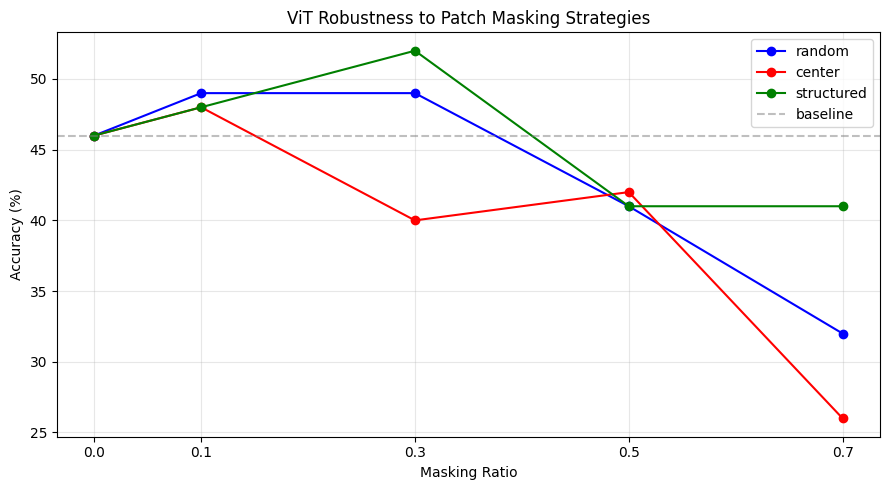

In [27]:
# ── 8. Plot ───────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(9, 5))

colors = {'random': 'blue', 'center': 'red', 'structured': 'green'}
for mask_type in mask_types:
    ax.plot(mask_ratios, results[mask_type], '-o',
            color=colors[mask_type], label=mask_type)

ax.axhline(y=baseline_acc, color='gray', linestyle='--', alpha=0.5, label='baseline')
ax.set_xlabel('Masking Ratio')
ax.set_ylabel('Accuracy (%)')
ax.set_title('ViT Robustness to Patch Masking Strategies')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xticks(mask_ratios)

plt.tight_layout()
plt.savefig('task2_4_patch_masking.png', dpi=150, bbox_inches='tight')
plt.show()

In [28]:
# ── 9. Summary table ──────────────────────────────────────────────────────────

print(f"\n{'Ratio':<8}", end='')
for mt in mask_types:
    print(f"{mt:>12}", end='')
print()
print("-" * 44)
for i, ratio in enumerate(mask_ratios):
    print(f"{ratio:<8.1f}", end='')
    for mt in mask_types:
        print(f"{results[mt][i]:>11.1f}%", end='')
    print()


Ratio         random      center  structured
--------------------------------------------
0.0            46.0%       46.0%       46.0%
0.1            49.0%       48.0%       48.0%
0.3            49.0%       40.0%       52.0%
0.5            41.0%       42.0%       41.0%
0.7            32.0%       26.0%       41.0%


2.5: CLS Token vs. Mean-Pooled Patch Tokens

In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import torch

In [30]:
# ── 1. Hook to extract full encoder output ────────────────────────────────────
# We need all 197 token embeddings (CLS + 196 patches) from the final encoder layer
# NOT the classification head output — that's already post-pooling

token_store = {}

def token_hook(module, input, output):
    # output: (batch, 197, 768) — full sequence before classification head
    token_store['tokens'] = output.detach().cpu()

# Hook into the encoder (before the classification head)
encoder_output_hook = model_vit.encoder.register_forward_hook(token_hook)
print("Encoder output hook registered")

Encoder output hook registered


In [31]:
# ── 2. Feature extraction helper ──────────────────────────────────────────────
def extract_features(model, img_pil, transform, device):
    """
    Returns:
      cls_feat  : (768,) numpy — CLS token embedding
      mean_feat : (768,) numpy — mean of 196 patch embeddings
    """
    x = transform(img_pil).unsqueeze(0).to(device)
    with torch.no_grad():
        _ = model(x)

    tokens = token_store['tokens'][0]   # (197, 768)
    cls_feat  = tokens[0].numpy()       # CLS token
    mean_feat = tokens[1:].mean(dim=0).numpy()   # mean of 196 patches

    return cls_feat, mean_feat

In [32]:
# ── 3. Stream ImageNet samples for the probe ──────────────────────────────────
# We need enough samples to train and test a linear classifier meaningfully
# 300 train + 100 test should be sufficient for a linear probe comparison

# 400 train + 100 test = 500 samples total

stl10_transformed = torchvision.datasets.STL10(
    root='./data', split='test', download=False,
    transform=vit_transform
)

N_TRAIN = 400
N_TEST  = 100

rng     = np.random.default_rng(42)
indices = rng.choice(len(stl10_transformed), size=N_TRAIN + N_TEST, replace=False)
subset  = Subset(stl10_transformed, indices)
loader  = DataLoader(subset, batch_size=32, shuffle=False, num_workers=2)

# Extract features
cls_features  = []
mean_features = []
labels_list   = []

print("Extracting features from STL-10...")
model_vit.eval()
for imgs, labels in tqdm(loader):
    imgs = imgs.to(device)
    with torch.no_grad():
        _ = model_vit(imgs)
    tokens = token_store['tokens']              # (batch, 197, 768)
    cls_features.append(tokens[:, 0, :].numpy())
    mean_features.append(tokens[:, 1:, :].mean(dim=1).numpy())
    labels_list.append(labels.numpy())

cls_features  = np.concatenate(cls_features,  axis=0)
mean_features = np.concatenate(mean_features, axis=0)
labels_arr    = np.concatenate(labels_list,   axis=0)

print(f"Extracted features: {cls_features.shape}")

Extracting features from STL-10...


100%|██████████| 16/16 [00:06<00:00,  2.34it/s]

Extracted features: (500, 768)


In [33]:
# ── 4. Train/test split ───────────────────────────────────────────────────────
X_cls_train,  X_cls_test  = cls_features[:N_TRAIN],  cls_features[N_TRAIN:]
X_mean_train, X_mean_test = mean_features[:N_TRAIN], mean_features[N_TRAIN:]
y_train, y_test           = labels_arr[:N_TRAIN],    labels_arr[N_TRAIN:]

print(f"Train: {len(y_train)} samples | Test: {len(y_test)} samples")
print(f"Unique classes in split: {len(np.unique(y_train))}")

Train: 400 samples | Test: 100 samples
Unique classes in split: 10


In [34]:
# ── 5. Normalize features ─────────────────────────────────────────────────────
# StandardScaler is standard practice before logistic regression
scaler_cls  = StandardScaler()
scaler_mean = StandardScaler()

X_cls_train_scaled  = scaler_cls.fit_transform(X_cls_train)
X_cls_test_scaled   = scaler_cls.transform(X_cls_test)

X_mean_train_scaled = scaler_mean.fit_transform(X_mean_train)
X_mean_test_scaled  = scaler_mean.transform(X_mean_test)

In [35]:
# ── 6. Train linear probes ────────────────────────────────────────────────────
print("\nTraining linear probes...")

clf_cls = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
clf_cls.fit(X_cls_train_scaled, y_train)
acc_cls_train = accuracy_score(y_train, clf_cls.predict(X_cls_train_scaled)) * 100
acc_cls_test  = accuracy_score(y_test,  clf_cls.predict(X_cls_test_scaled))  * 100
print(f"  CLS token   — Train: {acc_cls_train:.2f}%  Test: {acc_cls_test:.2f}%")

clf_mean = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
clf_mean.fit(X_mean_train_scaled, y_train)
acc_mean_train = accuracy_score(y_train, clf_mean.predict(X_mean_train_scaled)) * 100
acc_mean_test  = accuracy_score(y_test,  clf_mean.predict(X_mean_test_scaled))  * 100
print(f"  Mean pooling — Train: {acc_mean_train:.2f}%  Test: {acc_mean_test:.2f}%")


Training linear probes...
  CLS token   — Train: 100.00%  Test: 97.00%
  Mean pooling — Train: 100.00%  Test: 92.00%


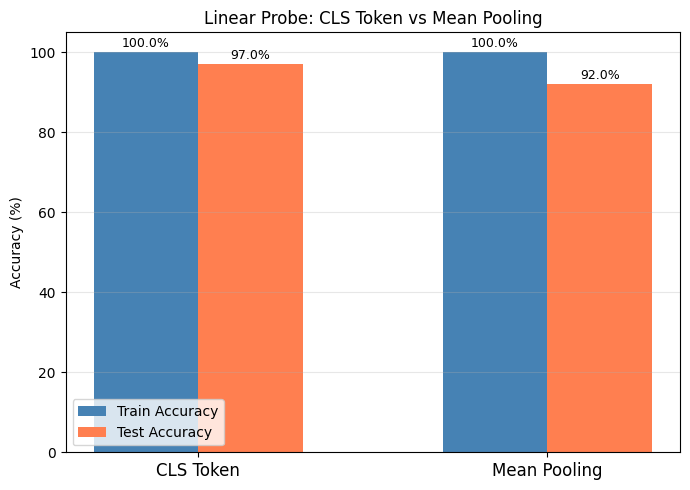

In [36]:
# ── 7. Plot comparison ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))

x      = np.arange(2)
width  = 0.3
train_accs = [acc_cls_train, acc_mean_train]
test_accs  = [acc_cls_test,  acc_mean_test]

bars1 = ax.bar(x - width/2, train_accs, width, label='Train Accuracy', color='steelblue')
bars2 = ax.bar(x + width/2, test_accs,  width, label='Test Accuracy',  color='coral')

ax.set_xticks(x)
ax.set_xticklabels(['CLS Token', 'Mean Pooling'], fontsize=12)
ax.set_ylabel('Accuracy (%)')
ax.set_title('Linear Probe: CLS Token vs Mean Pooling')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Annotate bars
for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('task2_5_pooling_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [37]:
# ── 8. Summary ────────────────────────────────────────────────────────────────

print("\n===== Linear Probe Summary =====")
print(f"{'Method':<15} {'Train Acc':>12} {'Test Acc':>12}")
print("-" * 40)
print(f"{'CLS Token':<15} {acc_cls_train:>11.2f}% {acc_cls_test:>11.2f}%")
print(f"{'Mean Pooling':<15} {acc_mean_train:>11.2f}% {acc_mean_test:>11.2f}%")
print(f"\nWinner: {'CLS Token' if acc_cls_test > acc_mean_test else 'Mean Pooling'}")

# Remove hook after use
encoder_output_hook.remove()
print("\nEncoder output hook removed")


===== Linear Probe Summary =====
Method             Train Acc     Test Acc
----------------------------------------
CLS Token            100.00%       97.00%
Mean Pooling         100.00%       92.00%

Winner: CLS Token

Encoder output hook removed
